In [ ]:
!pip install bertopic
!pip install nltk
# !pip install keybert
# !pip install keyphrase-vectorizers
# !pip install ctransformers[cuda]
# !pip install --upgrade git+https://github.com/huggingface/transformers

In [ ]:
import pandas as pd
import numpy as np
import torch
import transformers
from bertopic import BERTopic
import os
from sentence_transformers import SentenceTransformer
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
# from keybert import KeyBERT
# from ctransformers import AutoModelForCausalLM
from transformers import AutoTokenizer, pipeline
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import TextGeneration
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import openai
import lightgbm as lgb
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, OpenAI, PartOfSpeech
# from keyphrase_vectorizers import KeyphraseCountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.decomposition import PCA
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read Data

In [ ]:
os.chdir('/content/drive/My Drive/NLP-Letters-V2/notebooks/')
df1 = pd.read_csv('../data/letters_2021_processed.csv')
df1 = df1[['s1_s2', 'full_text', 'LETTER_GENDER']]
df1 = df1.rename(columns={'LETTER_GENDER':'label'})

In [ ]:
df2 = pd.read_csv('../data/sentence_sets_trimmed_processed.csv')
df2 = df2[['s1_s2', 'full_text', 'applicant_gender']]
df2 = df2.rename(columns={'applicant_gender':'label'})

In [ ]:

df = pd.concat([df1, df2], ignore_index=True)

In [ ]:
gender_label_mapping = {
    'F':0,
    'female':0,
    'M':1,
    'male':1
}

In [ ]:
df['label'] = df['label'].replace(gender_label_mapping)

# Process Data

In [ ]:
df['s1_s2'] = df['s1_s2'].str.replace(r'identifier', '', case=False, regex=True).str.strip()
df['s1_s2'] = df['s1_s2'].str.replace(r'mx', '', case=False, regex=True).str.strip()

In [ ]:
letters = df['s1_s2']
sentences = [sent_tokenize(letter) for letter in letters]
sentences = pd.concat([df, pd.Series(sentences, name='sentences')], axis=1)
sentences = sentences[['sentences']].explode('sentences')
df_sentences = pd.merge(df, sentences, left_index=True, right_index=True)

# Topic Modeling

In [ ]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embeddings = embedding_model.encode(sentences['sentences'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/4850 [00:00<?, ?it/s]

In [ ]:
# umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# hdbscan_model = HDBSCAN(min_cluster_size=500, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

pca_model = PCA(n_components=5, random_state=42)

kmeans_model = KMeans(n_clusters=60, random_state=42, n_init="auto")

vectorizer_model = CountVectorizer(stop_words='english', min_df=2, ngram_range=(1, 2))

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

In [ ]:
# KeyBERT
keybert_model = KeyBERTInspired()

# Part-of-Speech
pos_model = PartOfSpeech("en_core_web_sm", top_n_words=10)

# MMR
mmr_model = MaximalMarginalRelevance(diversity=0.3)

# GPT-3.5
client = openai.OpenAI(api_key="sk-...")
prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: [KEYWORDS]

Based on the information above, extract a short but highly descriptive topic label of at most 5 words. Make sure it is in the following format:
topic: <topic label>
"""
openai_model = OpenAI(client, model="gpt-3.5-turbo", exponential_backoff=True, chat=True, prompt=prompt)

# All representation models
representation_model = {
    "KeyBERT": keybert_model,
    # "OpenAI": openai_model,  # Uncomment if you will use OpenAI
    "MMR": mmr_model,
    "POS": pos_model,
    # "zephyr": zephyr

}

In [ ]:
# seed_topic_list = [["hard working", "strong work ethic", "works hard", "motivated", "determined", "driven"],
#                    ["rapport", "bedside manner", "works well with patients", "patient care", "liked by patients", "interacted well with patients", "compassion", "empathy", "kind", "caring", "warm"],
#                    ["eager to learn", "curious", "asks questions", "willingness to learn", "learn"],
#                    ["bright", "intelligent", "smart", "knowledgeable", "clever", "competent"],
#                    ["strong student", "academic success", "did well in school", "undergrad", "medical school", "university", "academics"],
#                    ["lead", "command", "execute", "achieve", "direct", "initiate", "enforce", "propel"],
#                    ["autonomy", "self-reliance", "ownership", "self-starter"],
#                    ["anesthesia", "anesthesiology", "anesthetic"]]


# seed_topic_list = [["hard working", "work ethic", "works hard", "motivated", "determined", "driven", "dedication", "drive"],
#                     ["rapport", "bedside manner", "compassion", "empathy", "kind", "caring", "warm"],
#                     ["intelligent", "smart", "clever", "competent"],
#                     ["medical knowledge", "clinical knowledge", "clinical skills"],
#                     ["medical student", "medical school", "student", "school", "undergrad", "university", "academics", "medical student"],
#                     ["lead", "command", "direct", "initiate", "managed"],
#                     ["autonomy", "self-reliance", "ownership", "self-starter", "independent"],
#                     ["team-player", "colloborate", "cooperative", "team"],
#                     ["anesthesia", "anesthesiology", "anesthetic"],
#                     ["eager to learn", "curious", "asks questions", "learn"],
#                     ["humble", "respectful"],
#                     ["communicate", "communication"],
#                     ["dillident", "detail-oriented", "focused", "attentive"]]

In [ ]:
topic_model = BERTopic(

  # Pipeline models
  embedding_model=embedding_model,
  umap_model=pca_model,
  hdbscan_model=kmeans_model,
  vectorizer_model=vectorizer_model,
  ctfidf_model=ctfidf_model,
  representation_model=representation_model,

  # Hyperparameters
  top_n_words=10,
  verbose=True,
  # seed_topic_list=seed_topic_list
)

# Train model
topics, probs = topic_model.fit_transform(df_sentences['sentences'].tolist(), embeddings)



2025-02-14 02:40:08,357 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-02-14 02:40:08,627 - BERTopic - Dimensionality - Completed ✓
2025-02-14 02:40:08,632 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-02-14 02:40:10,530 - BERTopic - Cluster - Completed ✓
2025-02-14 02:40:10,556 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-02-14 02:40:28,501 - BERTopic - Representation - Completed ✓


# Save Model

In [ ]:
# embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
# topic_model.save("../saved_models/topic_models/", serialization="safetensors", save_ctfidf=True, save_embedding_model=embedding_model)

# Analyze Topics

In [ ]:
topic_info = topic_model.get_topic_info()

In [ ]:
topic_info

,Topic,Count,Name,Representation,KeyBERT,MMR,POS,Representative_Docs
0,0,3598,0_medical students_medical school_school_students,"[medical students, medical school, school, stu...","[medical students, medical student, undergradu...","[medical students, medical school, students wo...","[medical students, medical school, school, stu...",[has distinguished themself throughout under...
1,1,3469,1_physician_dr_clinician_care,"[physician, dr, clinician, care, patient care,...","[care patients, patients, patient care, clinic...","[clinician, patient care, physicians, resident...","[physician, clinician, care, patient care, cli...",[reference provided by: name i dr. i ins...
2,2,3466,2_medical knowledge_knowledge_clinical_clinica...,"[medical knowledge, knowledge, clinical, clini...","[clinical skills, clinical knowledge, knowledg...","[medical knowledge, clinical skills, level tra...","[medical knowledge, knowledge, clinical, clini...",[they comes prepared for all types of learnin...
3,3,3424,3_calm_attitude_demeanor_team player,"[calm, attitude, demeanor, team player, player...","[calm demeanor, enthusiastic competent, demean...","[demeanor, team player, positive attitude, wor...","[calm, attitude, demeanor, player, positive, p...",[they has a positive outlook and calm demeano...
4,4,3340,4_patients_patient_rapport_patient care,"[patients, patient, rapport, patient care, rap...","[clinical reasoning, patients, knew patients, ...","[patient care, rapport patients, staff, abilit...","[patients, patient, rapport, patient care, car...","[actively sought opportunities to learn, and w..."
5,5,3191,5_learn_eager_eager learn_tasks,"[learn, eager, eager learn, tasks, team, showe...","[learned quickly, knowledge, procedural skills...","[eager learn, tasks, improve, learned, knowled...","[eager, tasks, team, organized, player, rounds...","[they was punctual, motivated, eager to learn..."
6,6,3156,6_differential_rounds_diagnosis_diagnoses,"[differential, rounds, diagnosis, diagnoses, t...","[patient history, diagnoses treatment, diagnos...","[rounds, diagnosis, diagnoses, differential di...","[differential, rounds, diagnosis, diagnoses, t...",[during their presentations they was able ...
7,7,3155,7_internal medicine_internal_medicine clerkshi...,"[internal medicine, internal, medicine clerksh...","[medicine clerkship, medicine inpatient, inpat...","[internal medicine, medicine clerkship, inpati...","[internal medicine, internal, clerkship, medic...",[iam an academic hospitalist in internal medic...
8,8,3076,8_patients_bedside_patient_bedside manner,"[patients, bedside, patient, bedside manner, m...","[respectful patients, caring patients, patient...","[bedside manner, patients families, care patie...","[patients, bedside, patient, manner, families,...",[they was also an outstanding advocate for t...
9,9,3065,9_feedback_professionalism_professional_impressed,"[feedback, professionalism, professional, impr...","[students, teachable, skills, professionalism,...","[feedback, professionalism, professional, team...","[feedback, professionalism, professional, impr...",[beyond their intellect and clinical acumen ...


In [ ]:
topic_labels = topic_model.generate_topic_labels(nr_words=5,
                                                 topic_prefix=True,
                                                 word_length=100,
                                                 separator="||",
                                                 aspect=None)

In [ ]:
topic_model.set_topic_labels(topic_labels)

In [ ]:
topic_mapping = dict(zip(topic_model.get_topic_info()['Topic'], topic_model.get_topic_info()['CustomName']))
topic_mapping = {f'topic_{key}': value for key, value in topic_mapping.items()}

In [ ]:
df_sentences['topic'] = topics

# Create Topics Dataframe

In [ ]:
topics_df = df_sentences.copy()
topics_df['topic'] = topics_df['topic'].astype(str)
topics_df = topics_df.groupby(topics_df.index).agg({'topic':' '.join})
topics_df = pd.DataFrame(topics_df)
topics_df = topics_df['topic'].apply(lambda x:x.split(' '))
topics_df = topics_df.reset_index()
all_topics = set(cat for sublist in topics_df['topic'] for cat in sublist)
for topic in all_topics:
    topics_df[topic] = topics_df['topic'].apply(lambda x: 1 if topic in x else 0)
topics_df = topics_df.drop(columns=['index', 'topic'])
topics_df.columns = 'topic_' + topics_df.columns
df_sentences_collapsed = df_sentences[['s1_s2', 'full_text', 'label']].drop_duplicates()
topics_df = pd.merge(df_sentences_collapsed, topics_df, left_index=True, right_index=True)

# Build ML Model

In [ ]:
X = topics_df.drop(columns=['s1_s2', 'full_text', 'label'])
y = topics_df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
skf = StratifiedKFold(n_splits=5)

In [ ]:
clf = lgb.LGBMClassifier(is_unbalance=True, n_estimators = 2000, verbose=-1)

In [ ]:
best_classifier = None
best_f1_score = float('-inf')
for i, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    print(f"Fold {i}:")
    # print(f"  Train: index={train_index}")
    # print(f"  Test:  index={val_index}")

    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    clf.fit(X_train_fold, y_train_fold)

    y_pred = clf.predict(X_val_fold)

    print(classification_report(y_val_fold, y_pred))

    print(confusion_matrix(y_val_fold, y_pred))

    f1 = f1_score(y_val_fold, y_pred, average='weighted')

    if f1 > best_f1_score:
      print('BEST F1 SCORE: ', f1)
      best_f1_score = f1
      best_classifier = clf






Fold 0:
              precision    recall  f1-score   support

           0       0.35      0.20      0.25       446
           1       0.70      0.84      0.76       991

    accuracy                           0.64      1437
   macro avg       0.53      0.52      0.51      1437
weighted avg       0.59      0.64      0.60      1437

[[ 88 358]
 [162 829]]
BEST F1 SCORE:  0.6034650116102462
Fold 1:
              precision    recall  f1-score   support

           0       0.37      0.20      0.26       446
           1       0.70      0.85      0.77       991

    accuracy                           0.65      1437
   macro avg       0.54      0.52      0.52      1437
weighted avg       0.60      0.65      0.61      1437

[[ 91 355]
 [153 838]]
BEST F1 SCORE:  0.6110878592225601
Fold 2:
              precision    recall  f1-score   support

           0       0.30      0.16      0.21       446
           1       0.69      0.83      0.75       991

    accuracy                           0.6

Most Important Features:
                                              Feature  Importance
58    1||physician||dr||clinician||care||patient care        1529
17  0||medical students||medical school||school||s...        1441
9    3||calm||attitude||demeanor||team player||player        1399
8   10||personality||ethic||intelligent||work ethi...        1379
18  7||internal medicine||internal||medicine clerk...        1354
28  19||write||write letter||support application||...        1340
48  13||patients families||bedside||patients||fami...        1304
34  16||asset||resident||asset residency||asset pr...        1283
46  4||patients||patient||rapport||patient care||r...        1265
40  2||medical knowledge||knowledge||clinical||cli...        1259
55   12||peers||learn||team player||player||technical        1257
38  27||interpersonal||patient care||communication...        1207
3           5||learn||eager||eager learn||tasks||team        1177
31  31||anesthesiologist||anesthesiology resident|.

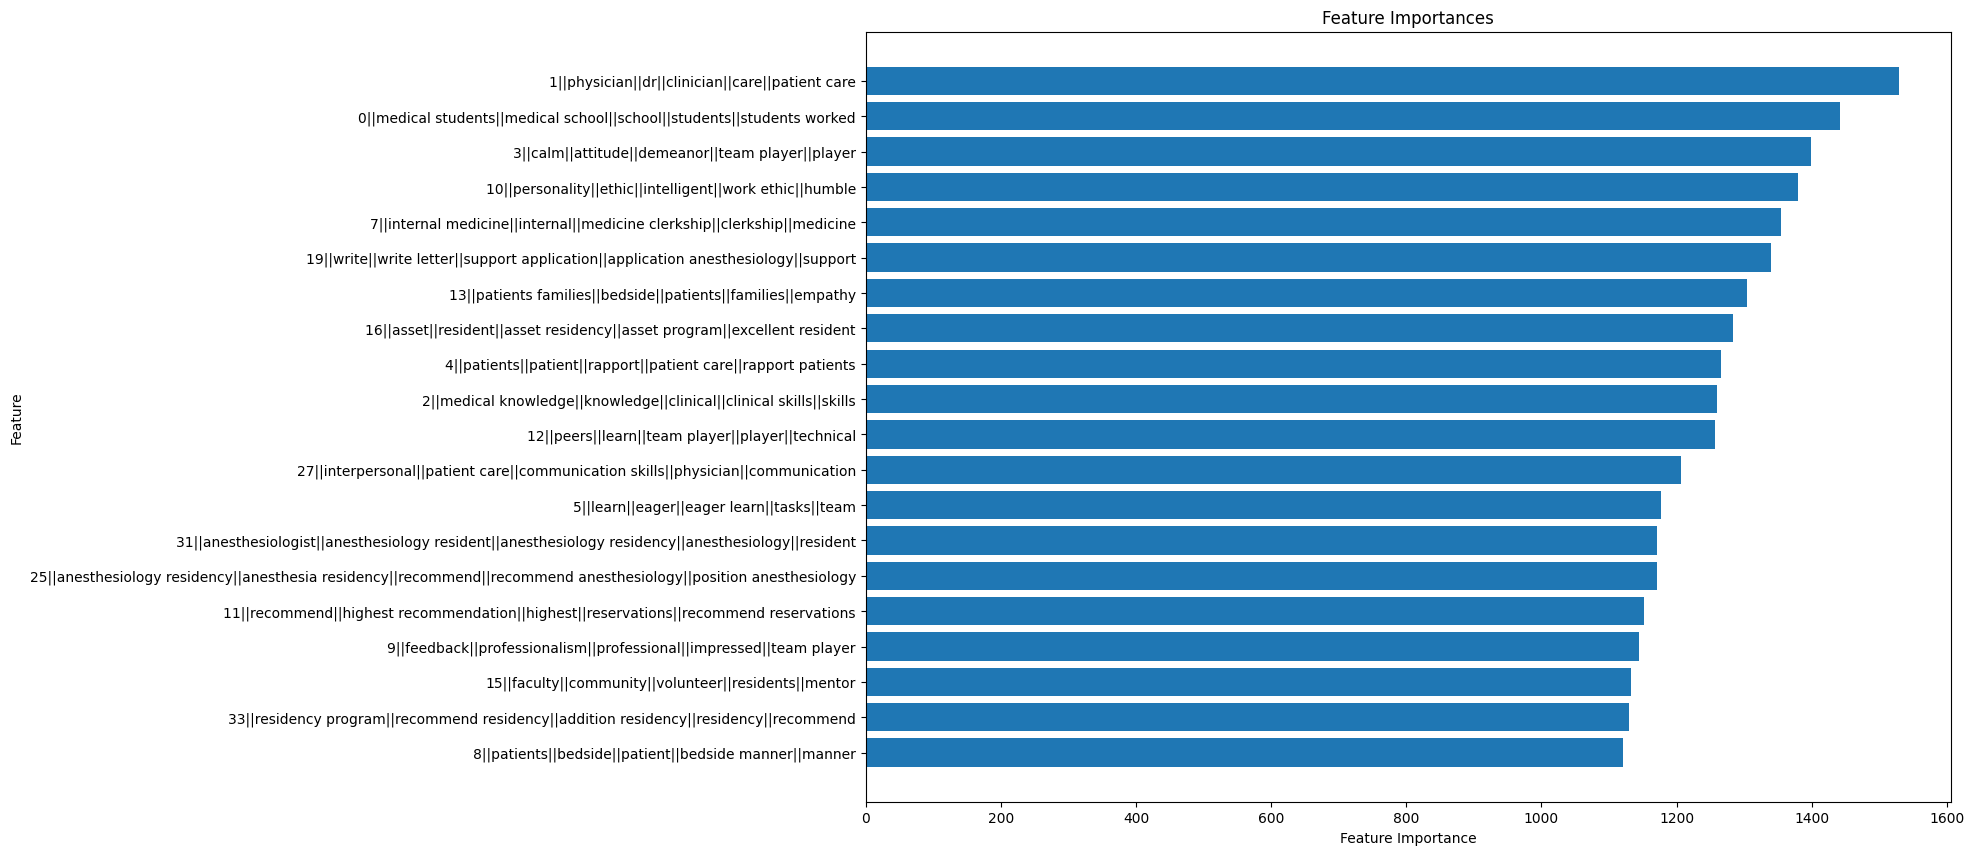

In [ ]:
importances = best_classifier.feature_importances_

feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)[:20]
feature_importance_df['Feature'] = feature_importance_df['Feature'].map(topic_mapping)

print("Most Important Features:")
print(feature_importance_df)

plt.figure(figsize=(14, 10))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')

plt.gca().invert_yaxis()

plt.show()

# Apply on Test Set

In [ ]:
y_test_preds = best_classifier.predict(X_test)

In [ ]:
print(classification_report(y_test, y_test_preds))

              precision    recall  f1-score   support

           0       0.28      0.14      0.19       557
           1       0.68      0.84      0.75      1239

    accuracy                           0.62      1796
   macro avg       0.48      0.49      0.47      1796
weighted avg       0.56      0.62      0.58      1796



# Analyze Important Topics

In [ ]:
reduced_embeddings = PCA(n_components=2).fit_transform(embeddings)
topic_model.visualize_documents(sentences['sentences'].tolist(), hide_annotations=True, reduced_embeddings=reduced_embeddings)

Output hidden; open in https://colab.research.google.com to view.